In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve, roc_auc_score

Zadanie 1 — Pierwszy model klasyfikacyjny
 Dopasuj prosty model regresji logistycznej do danych syntetycznych i sprawdź, czego się nauczył.
Wygeneruj syntetyczne dane z jedną cechą i binarną etykietą klasy (0/1), z szumem.
Utwórz model regresji logistycznej i dopasuj go do danych.
Odczytaj współczynniki: wagę cechy i wyraz wolny.
Narysuj punkty (kolorem wg klasy) oraz dopasowaną krzywą sigmoidalną.

+
Zadanie 2 — Predykcja i ocena modelu
 Sprawdź, jak dobrze model klasyfikuje nowe obserwacje.
Podziel dane na treningowe i testowe.
Dopasuj model na danych treningowych.
Wykonaj predykcję klas i prawdopodobieństw na danych testowych.
Policz accuracy, precision, recall, F1 i oceń model.



In [3]:
X, y = make_classification(
    n_samples=100, 
    n_features=1, #jedna cecha
    n_informative=1, #jedna cecha ma znaczenie dla wyniku
    n_redundant=0, #wylaczamy niepotrzebne kopie 
    n_clusters_per_class=1, # Każda klasa (0 i 1) tworzy jedną zwartą grupę
    flip_y=0.1, #Szum - losowo zamioenil 10 procent probek 
    random_state=42
)
#jedna cecha


In [4]:
dane = {"col1": X.flatten(), "col2": y}
df = pd.DataFrame(dane)
df

,col1,col2
0,0.819879,1
1,-1.242093,0
2,1.358547,0
3,1.813399,1
4,0.799142,1
...,...,...
95,-0.950264,0
96,-0.832703,0
97,-1.056758,0
98,1.664833,1


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

Użycie różnych liczb (jak 42 i 101) jest bardzo dobrą i powszechną praktyką. Pokazuje, że świadomie traktujesz generowanie danych oraz ich podział jako dwie odrębne operacje.

Różne wartości random_state rozdzielają od siebie dwa niezależne procesy losowe: tworzenie zbioru danych oraz jego podział na część treningową i testową. Pierwsza wartość (w make_classification) dba o to, aby model zawsze startował z tym samym układem cech i szumu. Druga wartość (w train_test_split) gwarantuje powtarzalne, stabilne losowanie próbek do testów, zapobiegając przypadkowemu wpływowi procesu generowania danych na ich późniejszy podział.

In [6]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [7]:
#model mowi ile szans jest na 0 i ile na 1
# np w pierwszym wierszu 95 procent szans na 1 a 5 proc na 0
model.predict_proba(X_test)

array([[0.04848302, 0.95151698],
       [0.97214545, 0.02785455],
       [0.87270529, 0.12729471],
       [0.07549161, 0.92450839],
       [0.95013077, 0.04986923],
       [0.93899316, 0.06100684],
       [0.9531177 , 0.0468823 ],
       [0.97358893, 0.02641107],
       [0.02271669, 0.97728331],
       [0.37928108, 0.62071892],
       [0.94480459, 0.05519541],
       [0.05583987, 0.94416013],
       [0.16068205, 0.83931795],
       [0.94158576, 0.05841424],
       [0.08324393, 0.91675607],
       [0.03018677, 0.96981323],
       [0.90538942, 0.09461058],
       [0.01280338, 0.98719662],
       [0.00469341, 0.99530659],
       [0.89718969, 0.10281031],
       [0.90086705, 0.09913295],
       [0.95630465, 0.04369535],
       [0.00201289, 0.99798711],
       [0.94784759, 0.05215241],
       [0.01745351, 0.98254649],
       [0.92802868, 0.07197132],
       [0.11984983, 0.88015017],
       [0.21176802, 0.78823198],
       [0.00834222, 0.99165778],
       [0.9241345 , 0.0758655 ]])

In [8]:
predictions = model.predict(X_test)
predictions

array([1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0])

In [9]:
#waga cechy 
waga = model.coef_

In [10]:
wyr_wolny = model.intercept_

In [11]:
#znajac prog mozemy poznac 9/10 probek bo 10% jest zamieniionych jako szum
prog = - wyr_wolny/waga
prog
#wynik -0.02 czyli jesli cecha x > -0.02 to prawdopodibienstwo wieksze od p> 0.5 i model przewiduje 1 klase i odwrotnie

array([[-0.02375483]])

In [12]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.93      0.88      0.90        16

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



1. Precision (Precyzja): Określa, ile z przewidzianych pozytywnych klas było faktycznie pozytywnych.
2. Recall (Czułość): Określa, ile z faktycznie pozytywnych klas zostało wykrytych przez model.
3. F1 score: Łączy oba te wskaźniki w jedną liczbę za pomocą średniej harmonicznej

4. Przykład dla 1:
   Precision (0.93):

   Gdy model przewiduje 1, ma rację w 93% przypadków.Recall (0.88): Model wykrył 88% wszystkich istniejących jedynek.F1-Score (0.90): Zbalansowana ocena (średnia) dla klasy 1.

In [13]:
confusion_matrix(y_test,predictions)


array([[13,  1],
       [ 2, 14]])

# TP FP
# FN TN

1. 13 Prawdziwe zera (model poprawnie wskazał 0) - TP
2. 1 Błąd – rzeczywiste zero uznane za 1. - FP
3. 2 Błąd – rzeczywista jedynka uznana za 0. - FN 
4. 14 Prawdziwe jedynki (model poprawnie wskazał 1). - TN

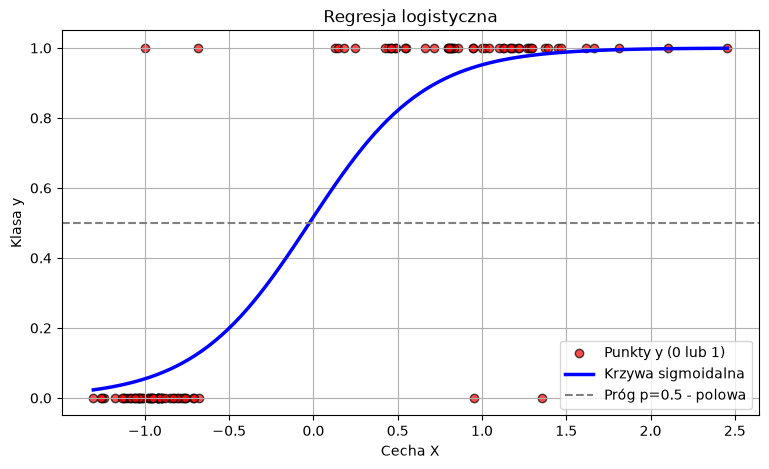

In [14]:
#tworzymy linie - 100 oznacza gladkosc 
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Prawdopodobieństwo z modelu z drugiej kolumny :1
y_proba = model.predict_proba(X_line)[:, 1]

plt.figure(figsize=(9, 5))

#Prawdziwe punkty 0 i 1
plt.scatter(
    X, y, color="red", alpha=0.7, edgecolors="k", label="Punkty y (0 lub 1)"
)

#Krzywa sigmoidalna
plt.plot(
    X_line, y_proba, color="blue", linewidth=2.5, label="Krzywa sigmoidalna"
)
#prog decyzyjny
plt.axhline(0.5, color="gray", linestyle="--", label="Próg p=0.5 - polowa")

plt.xlabel("Cecha X")
plt.ylabel("Klasa y")
plt.title("Regresja logistyczna")
plt.legend()
plt.grid(True)

Zadanie 3 — Próg decyzyjny i krzywa ROC
 Sprawdź, jak zmiana progu wpływa na klasyfikację.
Wygeneruj prawdopodobieństwa dla zbioru testowego.
Sprawdź wpływ progu (0.3, 0.5, 0.7) na macierz pomyłek.
Wyznacz krzywą ROC i policz AUC.
Wskaż najlepszy próg w danym kontekście.


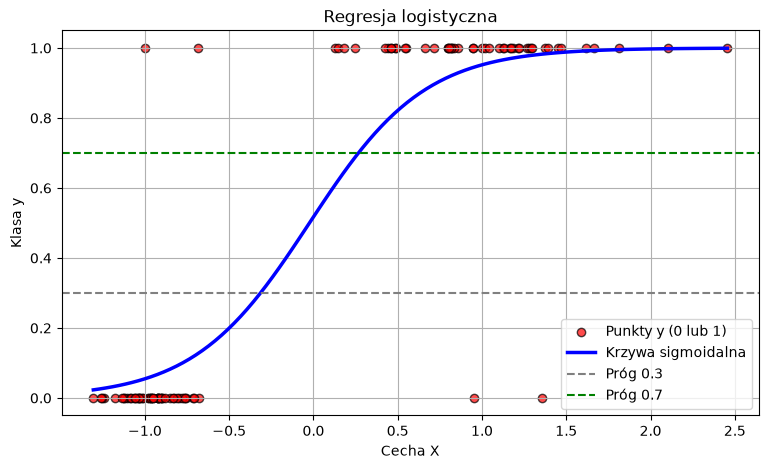

In [15]:
#zmieniajac prog na 0.3 lub 0.7 przesuwamy szara kreske w punkty 0.3 lub 0.7 na osi OY

#tworzymy linie - 100 oznacza gladkosc 
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Prawdopodobieństwo z modelu z drugiej kolumny :1
y_proba = model.predict_proba(X_line)[:, 1]

plt.figure(figsize=(9, 5))

#Prawdziwe punkty 0 i 1
plt.scatter(
    X, y, color="red", alpha=0.7, edgecolors="k", label="Punkty y (0 lub 1)"
)

#Krzywa sigmoidalna
plt.plot(
    X_line, y_proba, color="blue", linewidth=2.5, label="Krzywa sigmoidalna"
)
#progi decyzyjny
plt.axhline(0.3, color="gray", linestyle="--", label="Próg 0.3")
plt.axhline(0.7, color="green", linestyle="--", label="Próg 0.7")




plt.xlabel("Cecha X")
plt.ylabel("Klasa y")
plt.title("Regresja logistyczna")
plt.legend()
plt.grid(True)

In [16]:
#szansa na klase 1 w ulamkach
y_probs = model.predict_proba(X_test)[:, 1]
y_probs

array([0.95151698, 0.02785455, 0.12729471, 0.92450839, 0.04986923,
       0.06100684, 0.0468823 , 0.02641107, 0.97728331, 0.62071892,
       0.05519541, 0.94416013, 0.83931795, 0.05841424, 0.91675607,
       0.96981323, 0.09461058, 0.98719662, 0.99530659, 0.10281031,
       0.09913295, 0.04369535, 0.99798711, 0.05215241, 0.98254649,
       0.07197132, 0.88015017, 0.78823198, 0.99165778, 0.0758655 ])

In [17]:
#probki, odpowiedzi
X_test, y_test

(array([[ 0.99715802],
        [-1.24209292],
        [-0.68396821],
        [ 0.83542098],
        [-1.03449967],
        [-0.96132302],
        [-1.05675818],
        [-1.2608512 ],
        [ 1.26631756],
        [ 0.1451833 ],
        [-0.99777056],
        [ 0.94604581],
        [ 0.54319943],
        [-0.97716178],
        [ 0.79900835],
        [ 1.16618361],
        [-0.7983435 ],
        [ 1.46642399],
        [ 1.81339875],
        [-0.76671851],
        [-0.78061289],
        [-1.08204625],
        [ 2.10465976],
        [-1.01832197],
        [ 1.35854748],
        [-0.90061131],
        [ 0.66003987],
        [ 0.42698657],
        [ 1.6148837 ],
        [-0.88109758]]),
 array([1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
        1, 0, 0, 0, 1, 1, 1, 0]))

In [18]:
preds_03 = (y_probs >= 0.3).astype(int)
preds_05 = (y_probs >= 0.5).astype(int)
preds_07 = (y_probs >= 0.7).astype(int)


In [19]:
print("\n Próg 0.3")
print(confusion_matrix(y_test, preds_03))

print("\n Próg 0.5")
print(confusion_matrix(y_test, preds_05))

print("\n Próg 0.7")
print(confusion_matrix(y_test, preds_07))


 Próg 0.3
[[13  1]
 [ 2 14]]

 Próg 0.5
[[13  1]
 [ 2 14]]

 Próg 0.7
[[13  1]
 [ 3 13]]


In [20]:
# im wyzsze tn + tp tym lepiej  czyli przekaatne 13 + 14 = 27
# FP prawy gorny - falszywy alarm - model powiedzial tak a rzeczywistosc byla nie. 
# FN model przeoczyl - okazja przeszla kolo nosa

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)
# 0.91 oznacza ze model ma wysoka zdolnosc do odrozniania klas
auc

0.9151785714285714

In [22]:
fpr, tpr

(array([0.        , 0.        , 0.        , 0.07142857, 0.07142857,
        0.57142857, 0.57142857, 1.        ]),
 array([0.    , 0.0625, 0.25  , 0.25  , 0.9375, 0.9375, 1.    , 1.    ]))

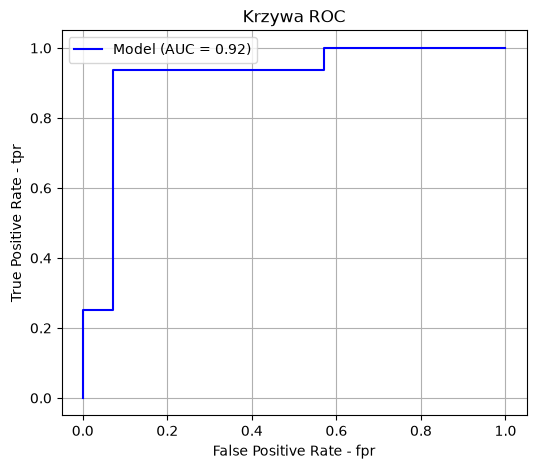

In [23]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Model (AUC = {auc:.2f})', color='blue')

plt.xlabel('False Positive Rate - fpr')
plt.ylabel('True Positive Rate - tpr')
plt.title('Krzywa ROC')
plt.legend()
plt.grid(True)
# auc 0.92 zamalowuje 92 proc wykresu calego 

TPR (True Positive Rate):To odsetek poprawnie wykrytych przypadków pozytywnych spośród wszystkich rzeczywiście pozytywnych w danych.Nazywany jest też czułością (sensitivity) lub pełnością (recall).Wzór:TPR = TP//TP+FN (gdzie TP to trafne pozytywne, a FN to fałszywe negatywne).Dąży do wartości 1.0 (100%)

FPR (False Positive Rate):To odsetek przypadków negatywnych, które model błędnie uznał za pozytywne, spośród wszystkich rzeczywiście negatywnych.Nazywany jest też współczynnikiem fałszywych alarmów.Wzór: FPR = FP//FP+TN (gdzie FP to fałszywe pozytywne, a TN to trafne negatywne).Dąży do wartości 0.0 (0%)

Zadanie 4 — Wykrywanie współliniowości
Przygotuj dane, gdzie jedna cecha to niemal liniowa kombinacja innej.
Napisz funkcję liczącą VIF dla każdej cechy.
Wypisz wyniki.
Wskaż kandydatów do usunięcia.


In [29]:
X_1, y_1 = make_classification(
    n_samples=200, 
    n_features=4, 
    n_informative=2, 
    n_redundant=1, #jedna cecha jest kombinacja dwoch cech  
    random_state=42
)

In [30]:
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1, y_1, test_size=0.3, random_state=42)

In [31]:
X_1_train

array([[-2.07728847e-01, -7.32397463e-02,  3.36416762e-01,
        -4.08075373e-01],
       [ 4.27120572e-02, -1.06467498e+00, -7.52371616e-01,
         3.32314012e-01],
       [ 8.46221452e-01, -5.42186718e-01, -1.90230651e+00,
         3.11250155e-01],
       [ 6.89828639e-01, -2.47044465e-01, -1.42738807e+00,
        -1.70338244e+00],
       [-1.35809531e+00, -9.88267315e-01,  1.87708853e+00,
        -1.21101620e+00],
       [ 8.05940100e-01,  1.33684127e-01, -1.40042867e+00,
         2.70456826e-01],
       [ 4.72691884e-01,  1.36823892e+00, -5.22699438e-03,
        -1.38279973e+00],
       [ 3.71704317e-01, -9.43772123e-01, -1.28206838e+00,
         1.96472513e+00],
       [-6.72079872e-01, -7.43208426e-01,  7.68103977e-01,
        -1.55677235e-01],
       [ 2.37294945e-02, -9.40573516e-01, -6.38869605e-01,
        -9.64923461e-01],
       [ 8.31861981e-02,  5.84983835e-01,  2.16869230e-01,
        -4.77657447e-01],
       [ 8.92501802e-01, -4.38517628e-01, -1.92198581e+00,
      

In [32]:
df = pd.DataFrame(X_1_train, columns=['Cecha_1', 'Cecha_2*', 'Cecha_3', 'Cecha_4'])
df

,Cecha_1,Cecha_2*,Cecha_3,Cecha_4
0,-0.207729,-0.073240,0.336417,-0.408075
1,0.042712,-1.064675,-0.752372,0.332314
2,0.846221,-0.542187,-1.902307,0.311250
3,0.689829,-0.247044,-1.427388,-1.703382
4,-1.358095,-0.988267,1.877089,-1.211016
...,...,...,...,...
135,-0.588624,0.670531,1.508869,0.235615
136,-1.261414,-2.491406,0.747836,0.955142
137,-1.428461,0.366016,2.863664,1.006293
138,0.682760,2.008594,0.012887,1.523124


VIF sprawdza, czy zmienne niezależne w Twoim modelu nie są zbyt mocno ze sobą powiązane (czy nie dublują tej samej informacji).

In [41]:
import statsmodels.api as sm
from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_vif(df):
    #wyraz wolny musi byc zeby obliczenia byly prawidlowe
    df_z_wyraz_wolny = add_constant(df)
    l_kolumn = df_z_wyraz_wolny.shape[1]
    for i in range(l_kolumn):
        aktualny_vif = variance_inflation_factor(df_z_wyraz_wolny.values, i)
        print(f" wyniki vif {i} : {aktualny_vif}")

    return df_z_wyraz_wolny
    

check_vif(df)

 wyniki vif 0 : 1.0138538815445013
 wyniki vif 1 : inf
 wyniki vif 2 : inf
 wyniki vif 3 : inf
 wyniki vif 4 : 1.0003237859821155


,const,Cecha_1,Cecha_2*,Cecha_3,Cecha_4
0,1.0,-0.207729,-0.073240,0.336417,-0.408075
1,1.0,0.042712,-1.064675,-0.752372,0.332314
2,1.0,0.846221,-0.542187,-1.902307,0.311250
3,1.0,0.689829,-0.247044,-1.427388,-1.703382
4,1.0,-1.358095,-0.988267,1.877089,-1.211016
...,...,...,...,...,...
135,1.0,-0.588624,0.670531,1.508869,0.235615
136,1.0,-1.261414,-2.491406,0.747836,0.955142
137,1.0,-1.428461,0.366016,2.863664,1.006293
138,1.0,0.682760,2.008594,0.012887,1.523124


In [43]:
#wystarczy usunac jedna ceche zeby przerwac zaleznosc miedzy tymi 3 cechami 
#mozna tez po prostu pomnozyc jedna kolumne x2 i stworzyc tak to nowa ktora bedzie zalezna liniowo i wtedy ja usunac
# tak jak w REG LIN.

In [51]:
df_1 = df.copy()
df_1_clean = df_1.drop(columns=['Cecha_3'])
df_1_clean

check_vif(df_1_clean)

# teraz po usunieciu jednej cechy jest git

 wyniki vif 0 : 1.0138538815445013
 wyniki vif 1 : 1.253843627136305
 wyniki vif 2 : 1.2538348164177529
 wyniki vif 3 : 1.0003237859821155


,const,Cecha_1,Cecha_2*,Cecha_4
0,1.0,-0.207729,-0.073240,-0.408075
1,1.0,0.042712,-1.064675,0.332314
2,1.0,0.846221,-0.542187,0.311250
3,1.0,0.689829,-0.247044,-1.703382
4,1.0,-1.358095,-0.988267,-1.211016
...,...,...,...,...
135,1.0,-0.588624,0.670531,0.235615
136,1.0,-1.261414,-2.491406,0.955142
137,1.0,-1.428461,0.366016,1.006293
138,1.0,0.682760,2.008594,1.523124



Zadanie 5 — Regresja logistyczna wielu cech
Wygeneruj dane z kilkoma cechami i szumem.
Podziel dane, dopasuj model na treningowej części.
Porównaj wagi cech.
Oceń model (accuracy, F1) na zbiorze testowym.


In [55]:
X_2, y_2 = make_classification(
    n_samples=400, 
    n_features=4, 
    n_informative=2, 
    n_redundant=0, 
    random_state=42,
    flip_y = 0.05
)

X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(X_2, y_2, test_size=0.3, random_state=42)

In [56]:
model = LogisticRegression()
model.fit(X_2_train, y_2_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [57]:
model.coef_
#im wiekszy coef tym wiekszy wplyw na decyzje modelu

array([[-0.08425105, -0.06848211,  2.36608806, -0.10650463]])

In [59]:
predictions = model.predict(X_2_test)
predictions

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0])

In [60]:
y_2_test

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [61]:
residuals = y_2_test - predictions
residuals

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,
        0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0])

In [62]:
print(classification_report(y_2_test,predictions))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        66
           1       0.91      0.93      0.92        54

    accuracy                           0.93       120
   macro avg       0.92      0.93      0.92       120
weighted avg       0.93      0.93      0.93       120



Precision (Precyzja): Określa, jaki procent przykładów zaklasyfikowanych przez model do danej klasy był faktycznie poprawny. O

Recall (Czułość): Mierzy, jaki procent wszystkich rzeczywistych obiektów z danej klasy został wykryty przez model. Jest kluczowy, gdy przeoczenie ważnego przypadku niesie duże ryzyko.

F1-score: Średnia harmoniczna precyzji i czułości, dająca jeden zrównoważony wskaźnik jakości. Przydaje się szczególnie, gdy klasy w zbiorze są nierównoliczne.

Support (Liczebność): Rzeczywista liczba próbek danej klasy obecna w zbiorze testowym. Pozwala ocenić, czy wyliczone metryki opierają się na wystarczającej liczbie danych.

Accuracy (Dokładność): Procent wszystkich poprawnych predykcji spośród wszystkich wykonanych prób. Może być mylący, jeśli w zbiorze jedna z klas mocno dominuje.

Macro avg (Średnia makro): Zwykła średnia arytmetyczna metryk obliczona dla wszystkich klas, bez patrzenia na ich wielkość. Traktuje każdą klasę z jednakową wagą.

Weighted avg (Średnia ważona): Średnia metryk uwzględniająca liczebność (support) każdej z klas. Daje lepszy obraz całościowej wydajności, gdy klasy są nierówne.